# Notebook 5: Build Region Adjacency Graph

## Purpose

This notebook constructs a topological graph from the WGS84 regional aggregates generated in Notebook 4.

The resulting graph represents geometric adjacency between regions and forms the foundation for future transport network encoding. At this stage, connectivity is based solely on region boundaries and does not yet account for existing infrastructure.

Road, rail, marine, and pipeline networks will be incorporated in subsequent notebooks as modal layers that modify the base graph.

## Inputs

From Notebook 4:

- `canada_basemap_1deg_centroid.gpkg`

## Outputs

- `region_adjacency.csv`
- `region_adjacency.gpkg`
- `region_nodes.csv`
- `region_nodes.gpkg`

## Methodology

1. Load WGS84 regional polygons.
2. Assign stable region identifiers.
3. Compute polygon centroids.
4. Determine neighboring regions using rook adjacency (shared boundaries).
5. Calculate centroid-to-centroid distances.
6. Export node and edge tables for downstream geospatial and TEMOA applications.

## Notes

The adjacency graph represents potential spatial connectivity only.

Infrastructure availability and transport technologies are treated separately and will be introduced in later notebooks.

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
from geopy.distance import distance
import matplotlib.pyplot as plt

In [6]:
# =============================================================================
# Project directories
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_FILES = PROJECT_ROOT / "data_files"

RAW_DATA = DATA_FILES / "raw"
PROCESSED_DATA = DATA_FILES / "processed"

PROCESSED_BASEMAP = PROCESSED_DATA / "basemaps"
PROCESSED_GRAPH = PROCESSED_DATA / "graph"
PROCESSED_NRN = PROCESSED_DATA / "nrn"

# Create output directory
PROCESSED_GRAPH.mkdir(parents=True, exist_ok=True)

In [28]:
# =============================================================================
# User Inputs
# =============================================================================

BASEMAP_FILE = "canada_basemap_1deg_centroid.gpkg"

BASEMAP_STEM = Path(BASEMAP_FILE).stem

OUTPUT_GPKG = f"{BASEMAP_STEM}_neighbors.gpkg"
OUTPUT_CSV = f"{BASEMAP_STEM}_neighbors.csv"

In [29]:
# =============================================================================
# File Paths
# =============================================================================

BASEMAP_PATH = PROCESSED_BASEMAP / BASEMAP_FILE

OUTPUT_GPKG_PATH = PROCESSED_GRAPH / OUTPUT_GPKG
OUTPUT_CSV_PATH = PROCESSED_GRAPH / OUTPUT_CSV

In [30]:
# Load regional basemap.

regions = gpd.read_file(BASEMAP_PATH)

print(f"Loaded {len(regions):,} regions")
print(f"CRS: {regions.crs}")

regions.head()

# Check input columns.

regions.info()

Loaded 1,692 regions
CRS: EPSG:4326
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   lon_min         1692 non-null   float64 
 1   lon_max         1692 non-null   float64 
 2   lat_min         1692 non-null   float64 
 3   lat_max         1692 non-null   float64 
 4   lon             1692 non-null   float64 
 5   lat             1692 non-null   float64 
 6   region          1692 non-null   object  
 7   site_id         1692 non-null   object  
 8   resolution_deg  1692 non-null   float64 
 9   keep_method     1692 non-null   object  
 10  geometry        1692 non-null   geometry
dtypes: float64(7), geometry(1), object(3)
memory usage: 145.5+ KB


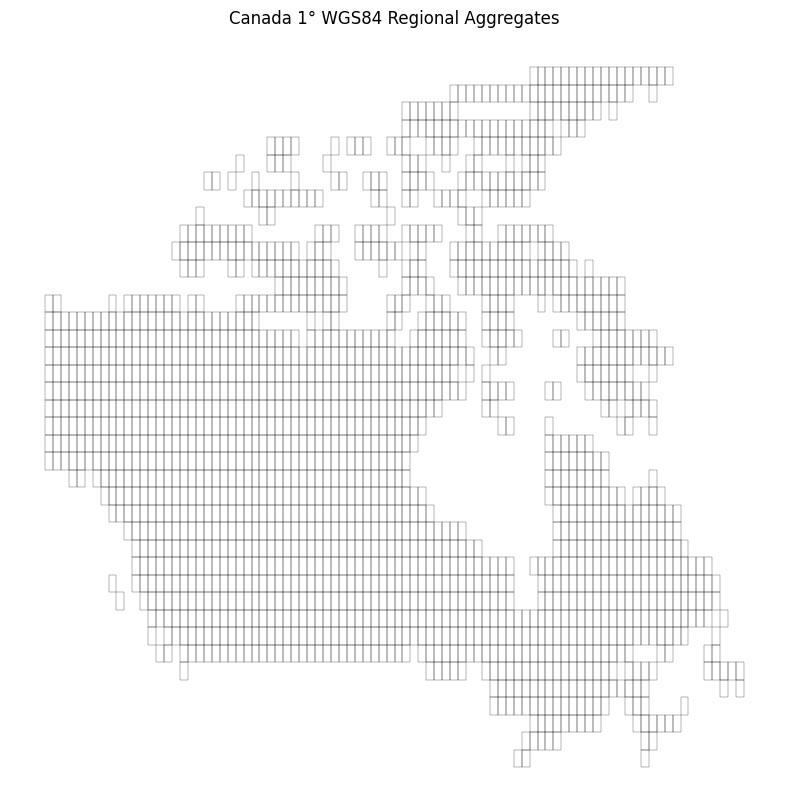

In [31]:
# Plot regional aggregates.

fig, ax = plt.subplots(figsize=(12, 10))

regions.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
    facecolor="none",
)

ax.set_title("Canada 1° WGS84 Regional Aggregates")
ax.set_axis_off()

plt.show()

In [32]:
# Inspect existing region identifiers.

regions[
    ["region", "site_id", "lon", "lat", "resolution_deg", "keep_method"]
].head()

,region,site_id,lon,lat,resolution_deg,keep_method
0,R0,R0,-81.5,43.5,1.0,centroid
1,R1,R1,-80.5,43.5,1.0,centroid
2,R2,R2,-65.5,43.5,1.0,centroid
3,R3,R3,-80.5,44.5,1.0,centroid
4,R4,R4,-79.5,44.5,1.0,centroid


In [33]:
# Validate region identifiers and coordinate pairs.

print(f"Unique region IDs: {regions['region'].nunique():,}")
print(f"Unique site IDs:   {regions['site_id'].nunique():,}")
print(f"Unique lon-lat pairs: {regions[['lon', 'lat']].drop_duplicates().shape[0]:,}")

assert regions["region"].is_unique
assert regions["site_id"].is_unique
assert regions[["lon", "lat"]].drop_duplicates().shape[0] == len(regions)

Unique region IDs: 1,692
Unique site IDs:   1,692
Unique lon-lat pairs: 1,692


In [34]:
# Extract grid resolution.

resolution_values = regions["resolution_deg"].unique()

assert len(resolution_values) == 1

resolution = float(resolution_values[0])

print(f"Grid resolution: {resolution} degrees")

Grid resolution: 1.0 degrees


In [35]:
# Create coordinate-to-region lookup.

coord_to_region = {
    (row.lon, row.lat): row.region
    for row in regions.itertuples(index=False)
}

In [36]:
# Assign cardinal neighbours.

regions["up_id"] = regions.apply(
    lambda row: coord_to_region.get((row["lon"], row["lat"] + resolution), "R-999"),
    axis=1,
)

regions["down_id"] = regions.apply(
    lambda row: coord_to_region.get((row["lon"], row["lat"] - resolution), "R-999"),
    axis=1,
)

regions["right_id"] = regions.apply(
    lambda row: coord_to_region.get((row["lon"] + resolution, row["lat"]), "R-999"),
    axis=1,
)

regions["left_id"] = regions.apply(
    lambda row: coord_to_region.get((row["lon"] - resolution, row["lat"]), "R-999"),
    axis=1,
)

regions[
    ["region", "lon", "lat", "up_id", "down_id", "right_id", "left_id"]
].head()

,region,lon,lat,up_id,down_id,right_id,left_id
0,R0,-81.5,43.5,R-999,R-999,R1,R-999
1,R1,-80.5,43.5,R3,R-999,R-999,R0
2,R2,-65.5,43.5,R8,R-999,R-999,R-999
3,R3,-80.5,44.5,R-999,R1,R4,R-999
4,R4,-79.5,44.5,R10,R-999,R5,R3


In [37]:
# Summarize neighbour counts.

neighbor_cols = ["up_id", "down_id", "right_id", "left_id"]

neighbor_summary = pd.DataFrame({
    "direction": neighbor_cols,
    "valid_neighbors": [
        (regions[col] != "R-999").sum()
        for col in neighbor_cols
    ],
    "missing_neighbors": [
        (regions[col] == "R-999").sum()
        for col in neighbor_cols
    ],
})

neighbor_summary

,direction,valid_neighbors,missing_neighbors
0,up_id,1408,284
1,down_id,1408,284
2,right_id,1535,157
3,left_id,1535,157


In [38]:


# Region lookup
region_lookup = (
    regions
    .set_index("region")[["lat", "lon"]]
    .to_dict("index")
)

In [39]:
# Calculate neighbour distances.

directions = ["up", "down", "right", "left"]

for direction in directions:

    distance_col = f"{direction}_distance"

    regions[distance_col] = np.nan

    for i, row in regions.iterrows():

        neighbor = row[f"{direction}_id"]

        if neighbor != "R-999":

            coord1 = (row["lat"], row["lon"])

            coord2 = (
                region_lookup[neighbor]["lat"],
                region_lookup[neighbor]["lon"]
            )

            regions.at[i, distance_col] = distance(
                coord1,
                coord2
            ).km

In [40]:
regions[
    [
        "region",
        "up_distance",
        "down_distance",
        "right_distance",
        "left_distance"
    ]
].head()

,region,up_distance,down_distance,right_distance,left_distance
0,R0,NaN,NaN,80.876192,NaN
1,R1,111.112243,NaN,NaN,80.876192
2,R2,111.112243,NaN,NaN,NaN
3,R3,NaN,111.112243,79.529066,NaN
4,R4,111.131778,NaN,79.529066,79.529066


In [41]:
# Summarize neighbor distances.

distance_cols = [
    "up_distance",
    "down_distance",
    "right_distance",
    "left_distance",
]

regions[distance_cols].describe()

,up_distance,down_distance,right_distance,left_distance
count,1408.000000,1408.000000,1535.000000,1535.000000
mean,111.407273,111.407273,53.231759,53.231759
std,0.131395,0.131395,15.511208,15.511208
min,111.112243,111.112243,14.577971,14.577971
25%,111.304994,111.304994,42.721895,42.721895
50%,111.412273,111.412273,54.955333,54.955333
75%,111.507421,111.507421,66.358509,66.358509
max,111.672085,111.672085,80.876192,80.876192


In [42]:
# Count valid neighbors.

regions["n_neighbors"] = (
    (regions["up_id"] != "R-999").astype(int)
    + (regions["down_id"] != "R-999").astype(int)
    + (regions["right_id"] != "R-999").astype(int)
    + (regions["left_id"] != "R-999").astype(int)
)

regions["n_neighbors"].value_counts().sort_index()

n_neighbors
0       9
1      58
2     170
3     332
4    1123
Name: count, dtype: int64

In [43]:
# Regions with no cardinal neighbors.

isolated_regions = regions.loc[
    regions["n_neighbors"] == 0,
    [
        "region",
        "lon",
        "lat"
    ]
]

isolated_regions

,region,lon,lat
43,R43,-60.5,46.5
299,R299,-55.5,51.5
300,R300,-131.5,52.5
371,R371,-132.5,53.5
1517,R1517,-97.5,74.5
1547,R1547,-117.5,76.5
1570,R1570,-116.5,77.5
1574,R1574,-105.5,77.5
1589,R1589,-104.5,78.5


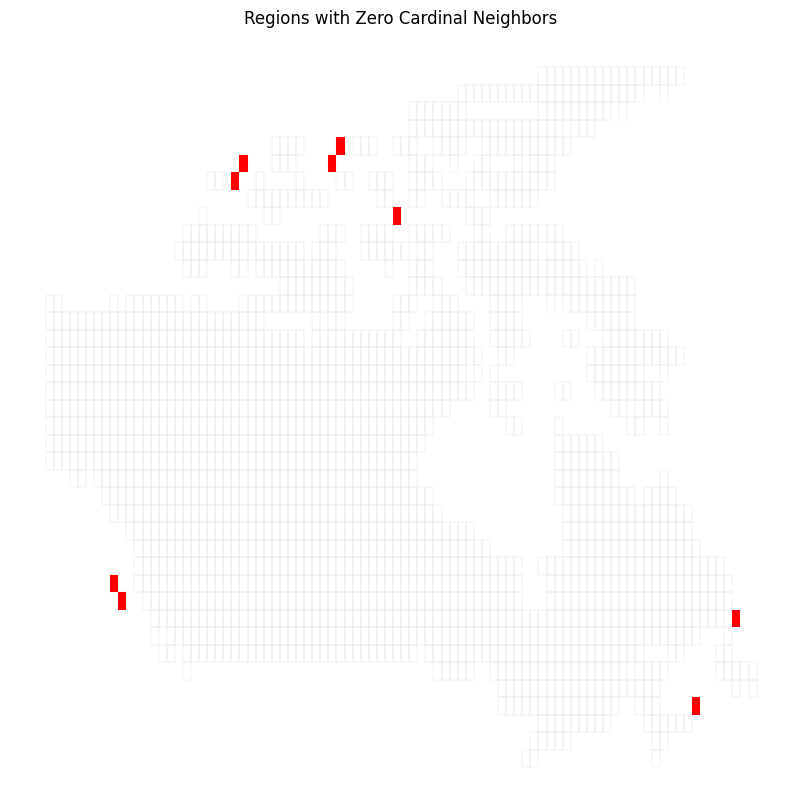

In [44]:
fig, ax = plt.subplots(figsize=(12,10))

regions.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.2,
)

regions.loc[
    regions["n_neighbors"] == 0
].plot(
    ax=ax,
    color="red"
)

ax.set_title("Regions with Zero Cardinal Neighbors")
ax.set_axis_off()

plt.show()

In [45]:
# Export neighbor-enriched regional basemap.

export_regions = regions.copy()

# Drop temporary geometry-like helper columns if present.
columns_to_drop = [
    col for col in ["centroid"]
    if col in export_regions.columns
]

if columns_to_drop:
    export_regions = export_regions.drop(columns=columns_to_drop)

# Export geospatial file for mapping and downstream spatial overlays.
export_regions.to_file(
    OUTPUT_GPKG_PATH,
    driver="GPKG",
)

# Export tabular file for schema/debugging workflows.
export_regions.drop(
    columns="geometry"
).to_csv(
    OUTPUT_CSV_PATH,
    index=False,
)

print(f"Exported GPKG: {OUTPUT_GPKG_PATH}")
print(f"Exported CSV:  {OUTPUT_CSV_PATH}")

Exported GPKG: c:\Users\aviga\Research\repos\temoa_geospace\data_files\processed\graph\canada_basemap_1deg_centroid_neighbors.gpkg
Exported CSV:  c:\Users\aviga\Research\repos\temoa_geospace\data_files\processed\graph\canada_basemap_1deg_centroid_neighbors.csv
